## Introduction

This notebook explores the standardization of restaurant menu items into a controlled taxonomy.
- Entree
- Side
- Drink
- Dessert
- Add-On

Restaurant-provided categories are inconsistent and often contain brand-specific naming conventions. This pipeline uses rule-based classification and calorie thresholds to normalize the categories. Accurate categorization is critical to EateryAI's recommendation engine because certain contraints will intentionally exclude specific categories.

### Issues with V1
In V1, category assignment relied primarily on substring keyword matching, but had several issues.
- Partial-word false positives
- Poor handling of plural keywords
- Over-weighting weak protein terms like "chicken"
- Inconsistent behavior across restaurants with different naming styles

---

### V2 Approach
The V2 pipeline improves the reliability and restaurant generalization of menu categorization by introducing three key upgrades: priority keyword matching, token-based text processing, and lightweight stemming. Together, these changes reduce false positives from the naive substring matching approach and make the system more robust to menu naming variation.
- Priority Keyword Matching
    - More imformative keywords take precedence over weaker ones
    - Strong entree signals (burrito, taco, sandwich, burger) indicate full meals and are evaluated with higher priority
    - Weak protein signals (chicken, beef, shrimp) are treated cautiously because they appear in both entrees and add-ons. These tokens no longer independently force an Add-On classification.
    - This priority system prevents cases such as:
        - Cantina Chicken Burrito being misclassified as an Add-On
        - Protein bowls being downgraded incorrectly
        - Extra protein add-ons being over-promoted
- Token-based Text Processing
    - Instead of substring matching, V2 will convert category and item name text into tokens and perform exact token matching.
        - This eliminates common substring errors and improves precision across large menu datasets.
        - Faster and more efficient set-based matching
- Lightweight Stemming
    - V2 will apply SnowballStemmer during token normalization
    - Improves keyword coverage without requiring manual enumeration of plural forms in the taxonomy for the token-based matching

### V2 Expectation
- Fewer false Add-On classifications
- Better handling of plural menu items
- Improved restaurant generalization
- More stable behavior on protein-heavy menus
- Higher overall precision without sacrificing speed

In [2]:

# !pip install matplotlib

In [3]:
import json
import copy
import matplotlib.pyplot as plt
from nltk import SnowballStemmer

stemmer = SnowballStemmer("english")

with open("../restaurants.menu_item_variations.json", "r") as f:
    data = json.load(f)

## 1. Defined Categories
Standardized category mapped to a set of common/restaurant specific categories identified from items that were not successfully recategorized.

### Categoization Steps

1) Restaurant Override - Some restaurants only include items of a single category like:
- Cold Stone Creamery (all items categorized as desserts)
- Cinnabon (all baked goods categorized as desserts)

2) Tokenized + Stemmed Keyword Matching
- Both the original category name and the menu item name are processed using:
    - Lowercasing
    - Tokenizing
    - Stemming
- The processed tokens are then matched against standardized keyword sets.
- Keyword Sources:
    - Common: burger, pasta, burrito, taco, salad
    - Restaurant-specific: zalad, blizzard, tastee-freez, crave coolers, moolattes
- Priority keyword rules:
    - High-confidence entree terms (burrito, bowl, combo) override weaker signals
    - Add-on indicators (extra, side of, add) are only applied when no entree keyword is present
    - Item name signals are weighted more heavily than restaurant category labels

3) Calories are used to resolve ambiguous cases. This helps differentiate 1) small snack vs full meals and 2) protein add-ons vs full protein entress:
- Side or Add-On items &ge; 450 calories &rarr; upgrade to Entree
- Items &le; 110 calories &rarr; classified as Add-On
- Items &ge; 900 calories &rarr; classified as Entree

In [ ]:
CATEGORIES_V2_RAW = {
    "Entree": {
        "entree", "breakfast", "lunch", "dinner", "soup", "salad", "burrito", "taco", "kabob", "fish", "meal",
        "sandwich", "steak", "bagel", "bowl", "plate", "wing", "tender", "seafood", "pizza", "pancake", "sirloin",
        "burger", "dog", "pasta", "quesadilla", "main", "stromboli", "calzone", "rice", "noodle", "build", "sub",
        "taquito", "slider", "pita", "zalad", "loco", "wrap", "panini", "focaccia", "ciabatta", "rib", "shepard",
        "poke", "meatloaf", "halibut", "bisque", "combo", "combination", "enchilada", "fajita", "tamales", "feast",
        "platter", "omelet", "waffle", "chili", "melt", "flatizza", "nacho", "specialties", "dim sum", "hoagie",
        "spud", "quiche", "salmon", "liver", "gizzard", "stir-fry", "piccata", "crab", "lobster", "chalupa",
        "filet", "menu hacks", "casserole", "bruschett", "oatmeal", "cereal", "porridge"
    },

    "Side": {
        "side", "starters", "chips", "snack", "munch", "appetizer", "edamame",
        "hummus", "fries", "popper", "bite", "fruit", "mac & cheese", "flatbread",
        "tornado", "dip", "potato", "pretzel", "croissant", "toast", "shareable",
        "pups", "hash", "nudies", "scone"
    },

    "Drink": {
        "drink", "beverage", "coffee", "water", "beer", "slush", "smoothie",
        "cocktail", "wine", "refresher", "tea", "blend", "cappuccino", "frappe",
        "lemonade", "mimosa", "margarita", "soda", "espresso", "juice", "limeade",
        "cervezas", "shots", "bloody mary", "slushie", "icee"
    },

    "Dessert": {
        "dessert", "ice cream", "custard", "shake", "cake", "yogurt", "donut",
        "doughnut", "float", "blizzard", "blast", "chocolate", "sundae", "freezee",
        "cooler", "brownie", "frosty", "caramel", "pie", "cookie", "pastries",
        "muffin", "bakery", "cone", "pudding", "icee", "danish", "mixer",
        "baked goods", "signature creations", "moolattes", "coolattas",
        "lemon ice", "concrete", "souffle", "fritter", "bundt", "cobbler",
        "pastry", "bars", "treat", "novelties", "julius"
    },

    "Add-On": {
        "topping", "condiment", "add", "add-on", "add on", "addon", "mix-in",
        "ingredient", "dressing", "sauce", "option", "avocado", "flavor",
        "aioli", "supplement", "family", "bread", "base", "components",
        "extra", "boost", "crust", "hot bar", "oil", "pesto", "guac",
        "vinaigrette", "spinach", "beans", "proteins", "cream cheese",
    }
}

# to help precompute category keywords for faster lookup during recategorization
CATEGORIES_V2 = {cat: {stemmer.stem(word) for word in words} for cat, words in CATEGORIES_V2_RAW.items()}

WEAK_PROTEINS = {stemmer.stem(w) for w in {"chicken","beef","pork","shrimp","steak","turkey","bacon"}}

SDAO_UPGRAGE_THRESHOLD = 450
LOW_CAL_ADDON_THRESHOLD = 110
HIGH_CAL_ENTREE_THRESHOLD = 900

FORCE_DESSERT_RESTAURANTS = {"Cold Stone Creamery", "Cinnabon"}

In [37]:

def restaurant_category_override(item):
    if item["restaurant_name"] in FORCE_DESSERT_RESTAURANTS:
        item["category"] = "Dessert"
        return True
    return False

def tokenize(string):
    return {stemmer.stem(word) for word in string.lower().split() if word.isalpha()} # TODO: check edge case with numbered items

def match_category(item_tokens, keywords):
    return not item_tokens.isdisjoint(keywords)

def protein_rule(tokens, cals):
    if not any(t in tokens for t in WEAK_PROTEINS):
        return None
    if cals >= 350:
        return "Entree"
    if cals <= 180:
        return "Add-On"
    return "Side"

In [38]:
def categorize_item(item):
    # check both category and item name
    cat = item["category"].lower()
    name = item["menu_item_name"].lower()
    cals = item["nutrition_info"]["calories"]

    if restaurant_category_override(item):
        item["recategorize_reason"] = "override"
        return "Dessert"
    
    name_tokens = tokenize(name)
    cat_tokens = tokenize(cat)
    
    # category match - highest priority
    for standardized_cat, keywords in CATEGORIES_V2.items():
        if match_category(cat_tokens, keywords):
            if standardized_cat in {"Side", "Add-On"} and cals >= SDAO_UPGRAGE_THRESHOLD:
                item["recategorize_reason"] = "calorie_upgrade_category"
                return "Entree"
            item["recategorize_reason"] = "category_match"
            return standardized_cat

    # name match - second priority
    for standardized_cat, keywords in CATEGORIES_V2.items():
        if match_category(name_tokens, keywords):
            if standardized_cat in {"Side", "Add-On"} and cals >= SDAO_UPGRAGE_THRESHOLD:
                item["recategorize_reason"] = "calorie_upgrade_name"
                return "Entree"
            item["recategorize_reason"] = "name_match"
            return standardized_cat
    
    # weak proteins
    protein_check = protein_rule(name_tokens.union(cat_tokens), cals)
    if protein_check:
        item["recategorize_reason"] = "protein_rule"
        return protein_check

    # calorie fallback
    if cals <= LOW_CAL_ADDON_THRESHOLD:
        item["recategorize_reason"] = "calorie_threshold"
        return "Add-On"
    elif cals >= HIGH_CAL_ENTREE_THRESHOLD:
        item["recategorize_reason"] = "calorie_threshold"
        return "Entree"
    return None

In [39]:
good_cat = []
bad_cat = []

# dup data
items = copy.deepcopy(data)


for item in items:
    new_cat = categorize_item(item)
    if new_cat:
        item["category"] = new_cat
        good_cat.append(item)
    else:
        bad_cat.append(item)

In [40]:
# print number of successful categorizations vs unknown
print(f"Successful: {len(good_cat)}")
print(f"Unknown: {len(bad_cat)}")

Successful: 34676
Unknown: 450


## File Output
corrected_category.json
- total count of successfully recategorized items
- all normalized items with updated categories

unknown_category.json
- used to identify keywords to add to defined category keywords
- could be used in the future to store items for manual review (some confidence score)

In [29]:
# dump successful/unknown categorizations
with open("generated_V2/corrected_category.json", "w") as correct:
    json.dump(good_cat, correct, indent=4)

with open("generated_V2/unknown_category.json", "w") as unknown:
    json.dump(bad_cat, unknown, indent=4)

In [30]:
for item in bad_cat:
    print(f"Name: {item['menu_item_name']}, Category: {item['category']}, Calories: {item['nutrition_info']['calories']}")

Name: Buffalo Chicken Roller, Category: Menu Items, Calories: 190
Name: Kid's Cheeseburger, Category: Kids Menu, Calories: 621
Name: Kid's Crispy Shrimp, Category: Kids Menu, Calories: 170
Name: Kid's Mozzarella Sticks, Category: Kids Menu, Calories: 340
Name: Kid's Macaroni & Cheese, Category: Kids Menu, Calories: 300
Name: Superfood Cranberry Almond Hot Cereal, Category: Oatmeal, Calories: 270
Name: Classic Oatmeal, Category: Oatmeal, Calories: 340
Name: Superfood Cranberry Almond Hot Cereal, Category: Oatmeal, Calories: 180
Name: Classic Oatmeal, Category: Oatmeal, Calories: 170
Name: Classic Oatmeal, Category: Oatmeal, Calories: 260
Name: Superfood Cranberry Almond Hot Cereal, Category: Oatmeal, Calories: 360
Name: Blueberry Scone, Category: Scones, Calories: 400
Name: Bacon, Category: Brunch Menu, Calories: 140
Name: Sausage Links, Category: Brunch Menu, Calories: 520
Name: Kids Milk, Category: Kids Menu, Calories: 140
Name: Kids Mist Twst, Category: Kids Menu, Calories: 130
Name:

## Edge Cases
- "add" being a keyword for Add-Ons could misclassify some entrees like "haddock" if the item is less than 450 calories

## Visualization and Exploration

In [22]:
# Unique categories before vs 5 standardized categorized now
unique_cats = {d["category"] for d in data}
print(f"Unique categories before: {len(unique_cats)}")

Unique categories before: 925


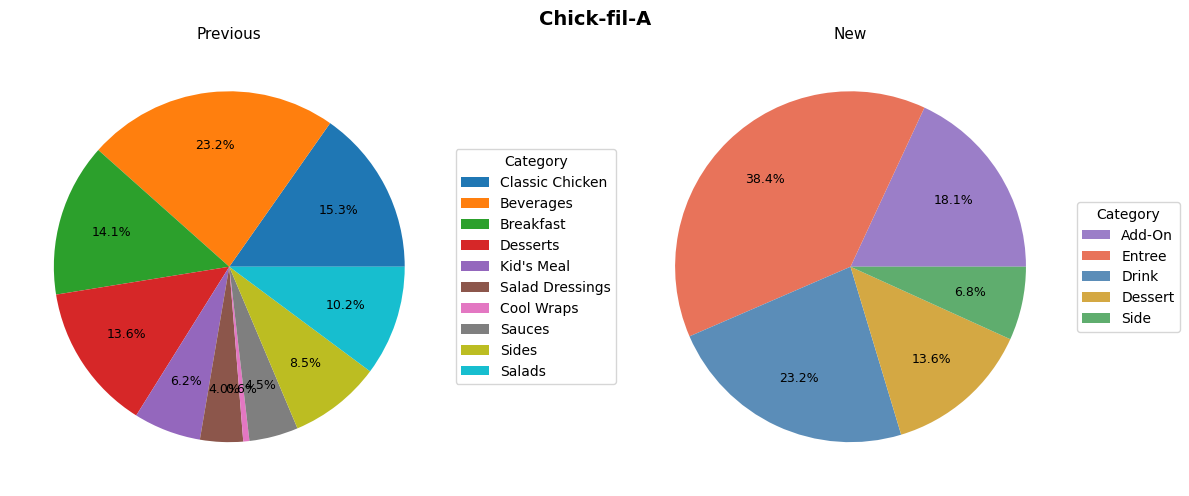

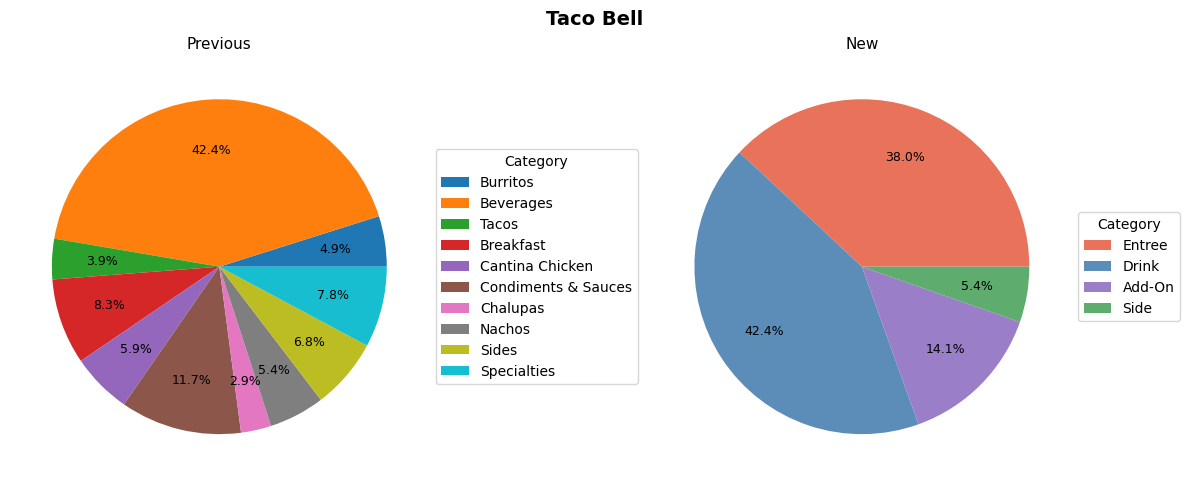

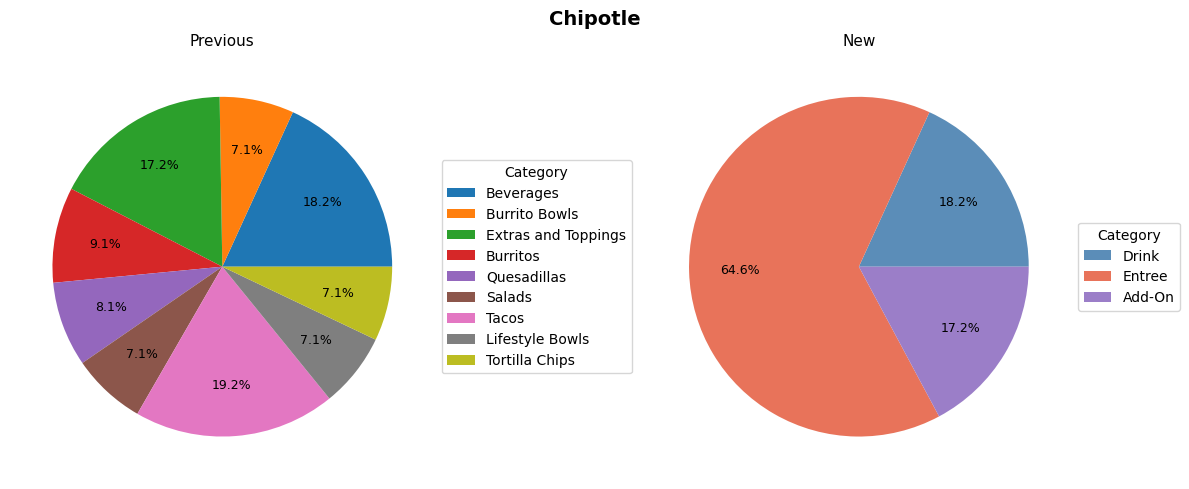

In [113]:
# Get items from Chick-fil-a, Taco Bell, and Chipotle
def get_selected_restaurants(items):
    cfa = []
    tb = []
    cp = []
    for item in items:
        if item["restaurant_name"] == "Chick-fil-A":
            cfa.append(item)
        elif item["restaurant_name"] == "Taco Bell":
            tb.append(item)
        elif item["restaurant_name"] == "Chipotle":
            cp.append(item)
    return cfa, tb, cp

# Get dict of category counts for each restaurant
def get_category_counts(items):
    category_counts = {}
    for item in items:
        cat = item["category"]
        if cat in category_counts:
            category_counts[cat] += 1
        else:
            category_counts[cat] = 1
    return category_counts

# Chick-fil-a, Taco Bell, Chiptole
prev_cfa, prev_tb, prev_cp = get_selected_restaurants(data)
new_cfa, new_tb, new_cp = get_selected_restaurants(good_cat)

prev_cfa_counts = get_category_counts(prev_cfa)
prev_tb_counts = get_category_counts(prev_tb)
prev_cp_counts = get_category_counts(prev_cp)
new_cfa_counts = get_category_counts(new_cfa)
new_tb_counts = get_category_counts(new_tb)
new_cp_counts = get_category_counts(new_cp)

CATEGORY_COLORS = {
    "Entree": "#E8735A",
    "Side": "#5FAD6E",
    "Drink": "#5B8DB8",
    "Add-On": "#9B7EC8",
    "Dessert": "#D4A843",
}

# Plotting the category distributions for each restaurant before and after categorization
def plot_category_distribution(prev_counts, new_counts, restaurant_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 12))
    fig.suptitle(restaurant_name, fontsize=14, fontweight='bold', y=.7)

    # Previous
    if prev_counts:
        wedges, _, _ = axes[0].pie(
            list(prev_counts.values()),
            labels=None,
            autopct='%1.1f%%',
            pctdistance=0.7,
            textprops={'fontsize': 9}
        )

        axes[0].legend(
            wedges,
            prev_counts.keys(),
            title="Category",
            loc="center left",
            bbox_to_anchor=(1, 0.5)
        )
        axes[0].set_title("Previous", fontsize=11)
    else:
        axes[0].set_title(f"Previous - {restaurant_name} (no data)")

    # New
    if new_counts:
        colors = [CATEGORY_COLORS.get(cat, "gray") for cat in new_counts.keys()]
        wedges, _, _ = axes[1].pie(
            list(new_counts.values()),
            labels=None,
            autopct='%1.1f%%',
            pctdistance=0.7,
            textprops={'fontsize': 9},
            colors=colors
        )

        axes[1].legend(
            wedges,
            new_counts.keys(),
            title="Category",
            loc="center left",
            bbox_to_anchor=(1, 0.5)
        )
        axes[1].set_title("New", fontsize=11)
    else:
        axes[1].set_title(f"New - {restaurant_name} (no data)")

    plt.tight_layout()
    plt.show()

plot_category_distribution(prev_cfa_counts, new_cfa_counts, "Chick-fil-A")
plot_category_distribution(prev_tb_counts, new_tb_counts, "Taco Bell")
plot_category_distribution(prev_cp_counts, new_cp_counts, "Chipotle")

In [57]:
from collections import Counter

reason_counts = Counter(item["recategorize_reason"] for item in good_cat)
print("Recategorization reason counts:")
for reason, count in reason_counts.items():
    print(f"{reason}: {count}")

Recategorization reason counts:
category_match: 33208
calorie_upgrade: 1007
calorie_threshold: 58
override: 853


In [114]:
from collections import Counter

reason_counts = Counter(item["recategorize_reason"] for item in good_cat)
print("Recategorization reason counts (all items):")
for reason, count in reason_counts.items():
    print(f"{reason}: {count}")

Recategorization reason counts (all items):
category_match: 31590
name_match: 458
calorie_upgrade_category: 1994
calorie_upgrade_name: 173
calorie_threshold: 58
override: 853


In [ ]:
# !pip install pandas

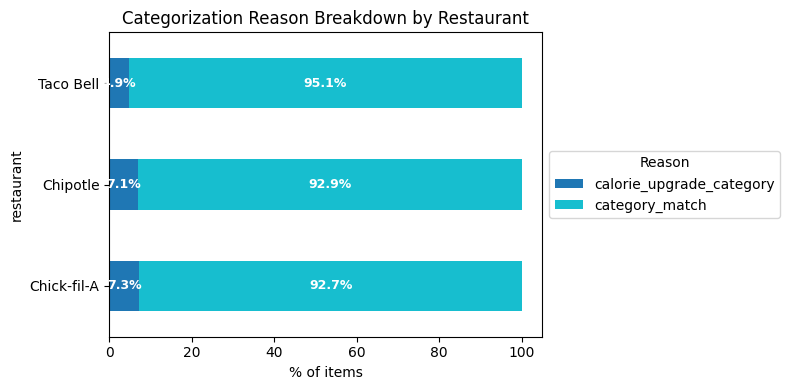

In [115]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_categorization_reasons(all_items):
    df = pd.DataFrame([
        {"restaurant": item["restaurant_name"], "recategorize_reason": item["recategorize_reason"]}
        for item in all_items
    ])

    counts = df.groupby(["restaurant", "recategorize_reason"]).size().unstack(fill_value=0)
    counts_pct = counts.div(counts.sum(axis=1), axis=0) * 100

    ax = counts_pct.plot(kind="barh", stacked=True, figsize=(8, 4), colormap="tab10")
    
    for bars in ax.containers:
        labels = [f"{v:.1f}%" if v >= 3 else "" for v in bars.datavalues]  # hide if too small
        ax.bar_label(bars, labels=labels, label_type="center", fontsize=9, color="white", fontweight="bold")

    ax.set_xlabel("% of items")
    ax.set_title("Categorization Reason Breakdown by Restaurant")
    ax.legend(title="Reason", bbox_to_anchor=(1, 0.5), loc="center left")
    plt.tight_layout()
    plt.show()

# combine new_cfa, new_tb, new_cp for plotting
new_items = new_cfa + new_tb + new_cp

plot_categorization_reasons(new_items)

## Manual Category Check for Chick-Fil-A, Taco Bell, Chipotle

Issues with category matching:
- White rice marked as Entree because "rice" was an entree keyword
- "Izze Sparkling Grapefruit Soda" was matching as Add-On because of "fruit" in item_name

**Fix: Changed algorithm to take two passes, prioritizing category match first**

Calorie upgrades from add-ons:
- (CP) "Chips" and "Chips & Tomatillo-Red Chili Salsa" are marked as Entree
- (CFA) "Waffle Fries", "Chicken Tortilla Soup", "Mac & Cheese" are marked as Entree

Issue with category match first:
- Taco Bell, matching "Cantina Chicken" category as Add-On because of "chicken" keyword and <450 calories

In [122]:
# comparing new vs old categorizations for each restaurant
def check_categorization_changes(new, prev, key):
    check = pd.merge(pd.DataFrame(new), pd.DataFrame(prev)[["menu_item_name", "category"]], how="left", on="menu_item_name", suffixes=("_new", "_old"))
    cats = check[["menu_item_name", "restaurant_name", "category_new", "category_old", "recategorize_reason", "nutrition_info"]].sort_values(by=["category_new", "category_old"])
    with open(f"generated/{key}_check.txt", "w") as f:
        f.write(cats.to_string())

check_categorization_changes(new_cfa, prev_cfa, "cfa")
check_categorization_changes(new_tb, prev_tb, "tb")
check_categorization_changes(new_cp, prev_cp, "cp")

## Breakfast Exploration